# 🛍️ Customer Segmentation — K-Means Clustering

## Project Overview
Used K-Means clustering to segment mall customers into 5 distinct groups based on income and spending behavior.

## Dataset
- 200 mall customers
- Features: Age, Annual Income, Spending Score

## Customer Segments Found
1. 🔵 VIP Spenders — High income, High spending (avg age 33)
2. 🟢 Young Wild Spenders — Low income, High spending (avg age 25)
3. 🔴 Average Joes — Medium income, Medium spending (avg age 43)
4. 🟠 Careful Rich — High income, Low spending (avg age 41)
5. 🟣 Budget Conscious — Low income, Low spending (avg age 45)

## Business Value
Each segment requires a different marketing strategy to maximize revenue.

## Tools Used
Python, Pandas, Scikit-learn, Matplotlib, Seaborn

## Author
**Faith Mwende** | [GitHub](https://github.com/Mwende-Fifi)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [3]:
# Load the dataset
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 5)

First 5 rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Exploring the data
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                int64
Genre                       str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Basic statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


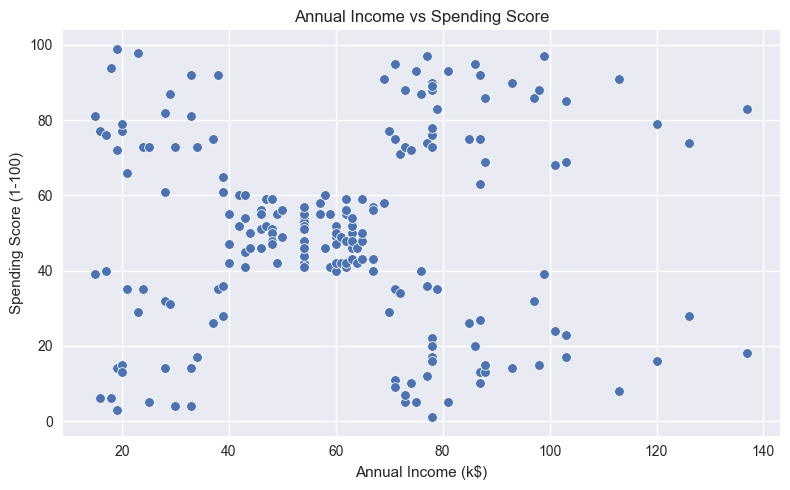

In [5]:
# Visualize Income vs Spending
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Annual Income (k$)',
                y='Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.tight_layout()
plt.show()

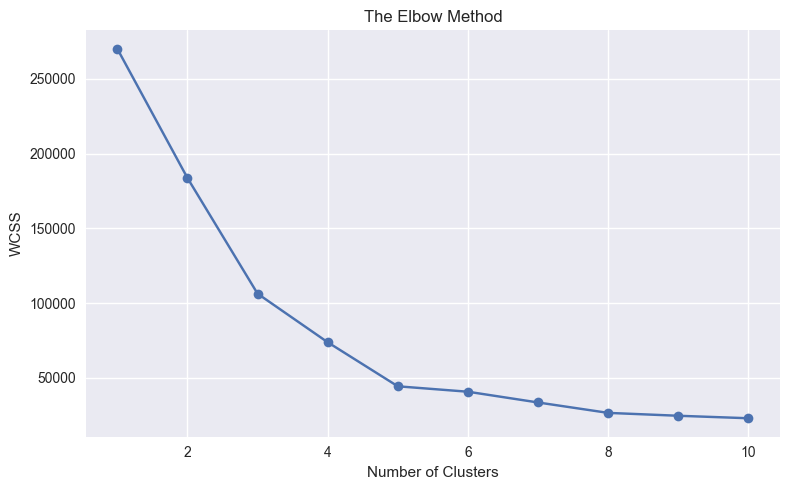

In [7]:
# Find optimal number of clusters (Elbow Method)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

wcss = []
for i  in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.tight_layout()
plt.show()

In [8]:
# Build the clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

print("Customers per cluster:")
print(df['Cluster'].value_counts())

Customers per cluster:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


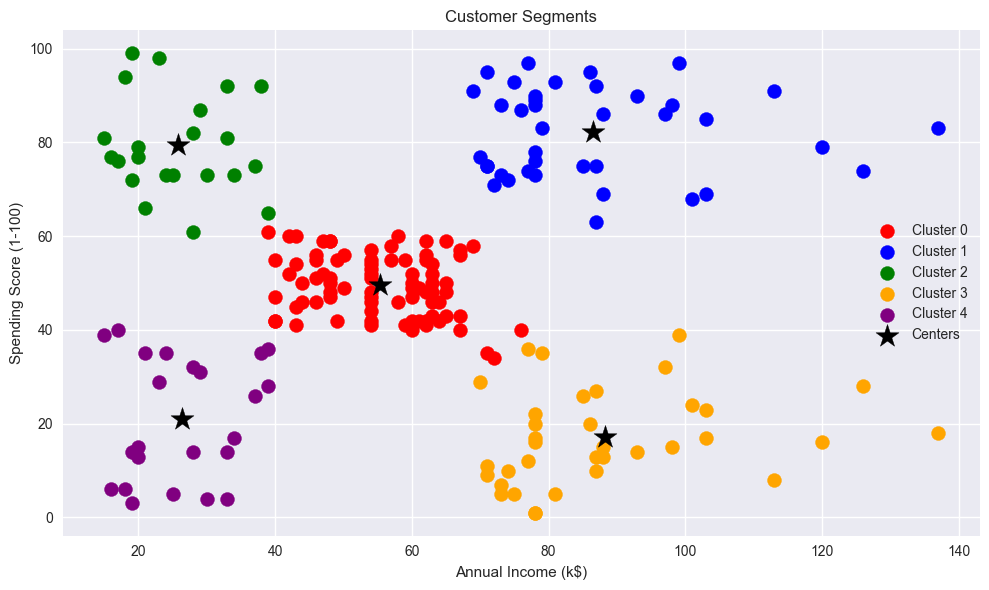

In [9]:
# Visualize the centers
plt.figure(figsize=(10,6))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(5):
    plt.scatter(
        df[df['Cluster']==i]['Annual Income (k$)'],
        df[df['Cluster']==i]['Spending Score (1-100)'],
        c=colors[i], label=f'Cluster {i}', s=100
    )

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='black', marker='*', s=300, label='Centers'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Summary statistics per cluster
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 
                       'Spending Score (1-100)']].mean().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91
